In [1]:
import class_nlp_train_model as nlptrain
import pandas as pd

#
obj_nlptrain = nlptrain.class_train_model()

#
df = pd.read_excel('DateToTestSentiment_20210817.xls.xls')

#
df_final = obj_nlptrain.preprocess_data(df, 
                                        columns = ['COMMENT_TEXT', 'RATING_VALUE'],
                                        label_column='RATING_VALUE', 
                                        null = True,
                                        labels_ok = False,
                                        dict_labels = {(' '): '', (','): '.'},
                                        labels_ready = False, 
                                        labels_true = {(5,5): 2, (4,4):0,(1,2,3):1}
                                       )

# contruindo a coluna nova com os sentimentos
df_final['sentimentos'] = df_final['RATING_VALUE'].apply(obj_nlptrain.sentimento)

#
df_final = obj_nlptrain.tokenizacao(df_final)

#
vectorize, lista_treino = obj_nlptrain.treinar_vetorizacao(df_final)

# criando a coluna com o texto vetorizado
df_final['vectors'] = df_final['token'].apply(obj_nlptrain.vectorize2)

#
df_final = obj_nlptrain.balance_classes(df_final)

# Criando datasets de teste e treino
X, y, Xtrain, Xtest, ytrain, ytest = obj_nlptrain.separa_df_test_train(df_final, 0.25)

#
model = obj_nlptrain.redes_neurais_modelo(lista_treino, Xtrain.shape[1]);

#
callbacks, history, model = obj_nlptrain.cria_stopper_rede(epo=1,
                                                           model=model,
                                                           Xtrain=Xtrain,
                                                           ytrain=ytrain,
                                                           Xtest=Xtest,
                                                           ytest=ytest
                                                           )

Model: "sequential"
_________________________________________________________________
Layer (type)                 Output Shape              Param #   
embedding (Embedding)        (None, 20, 128)           1841664   
_________________________________________________________________
dropout (Dropout)            (None, 20, 128)           0         
_________________________________________________________________
lstm (LSTM)                  (None, 512)               1312768   
_________________________________________________________________
dense (Dense)                (None, 256)               131328    
_________________________________________________________________
dropout_1 (Dropout)          (None, 256)               0         
_________________________________________________________________
dense_1 (Dense)              (None, 128)               32896     
_________________________________________________________________
dropout_2 (Dropout)          (None, 128)               0

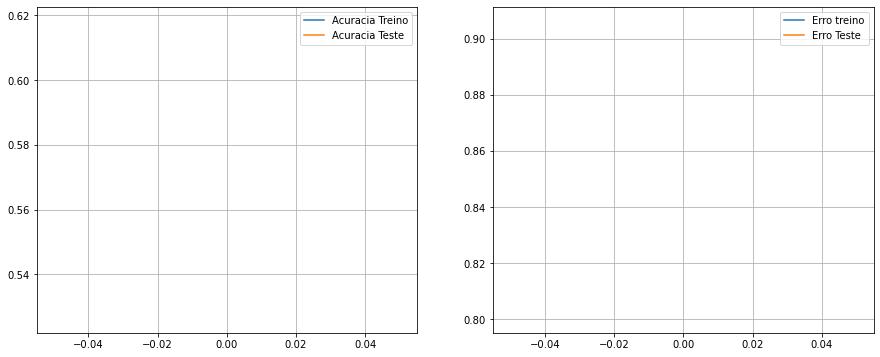

In [2]:
import matplotlib.pyplot as plt

plt.figure(figsize=[15,6])

plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Acuracia Treino')
plt.plot(history.history['val_accuracy'], label='Acuracia Teste')
plt.legend()
plt.grid()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Erro treino')
plt.plot(history.history['val_loss'], label='Erro Teste')
plt.legend()
plt.grid()

plt.show()

# Salva modelo e vectorize

In [3]:
from joblib import dump

dump(vectorize, 'vetorize_sklearn.joblib') 

model.save('model.h5')